# SV with Jumps and Factor SV

This notebook demonstrates two advanced extensions of the stochastic volatility model:

1. **SV with Jumps (SV-J)**: Adds Poisson-driven jumps to capture sudden large moves:
   $$y_t = \exp(h_t/2)\,\varepsilon_t + J_t\,Z_t$$
   where $J_t \sim \text{Bernoulli}(\lambda)$ and $Z_t \sim N(\mu_J, \sigma_J^2)$

2. **Factor SV**: A multivariate model with a common volatility factor driving
   $K$ correlated asset returns:
   $$y_{k,t} = \exp\bigl((\beta_k h_t + h_{k,t})/2\bigr)\,\varepsilon_{k,t}$$

We filter using the **Auxiliary Particle Filter** (for SV-J) and a simplified
**Rao-Blackwellized** approach (for Factor SV).

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from scipy import stats
import time

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..')))

from particlefilterbox.models.stochastic_volatility import StochasticVolatility

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)

## Part 1: SV with Jumps (SV-J)

### 1.1 Synthetic Data Generation

We generate data from the SV-J model using `particlefilterbox`.

In [2]:
# Generate data with the jumps variant
sv_jumps = StochasticVolatility(
    variant='jumps',
    params={
        'mu': -1.0, 'phi': 0.97, 'sigma': 0.15,
        'lambda_jump': 0.05,    # ~5% chance of jump each period
        'mu_jump': -0.5,        # negative mean jump (crash-like)
        'sigma_jump': 1.0,      # jump size std
    }
)

sim_j = sv_jumps.simulate(T=500, seed=42)
y_jumps = sim_j['observations'][:, 0]  # (T,)
h_true_j = sim_j['states'][:, 0]       # log-vol
q_true_j = sim_j['states'][:, 1]       # jump indicator

print(f'Generated {len(y_jumps)} observations')
print(f'Number of jumps: {int(q_true_j.sum())} ({q_true_j.mean()*100:.1f}%)')
print(f'Jump times: {np.where(q_true_j > 0.5)[0][:20]}...')

Generated 500 observations
Number of jumps: 29 (5.8%)
Jump times: [  1  94 100 111 132 148 150 153 165 176 177 224 237 245 260 266 272 293
 328 338]...


### 1.2 Exploratory Analysis of Jump Data

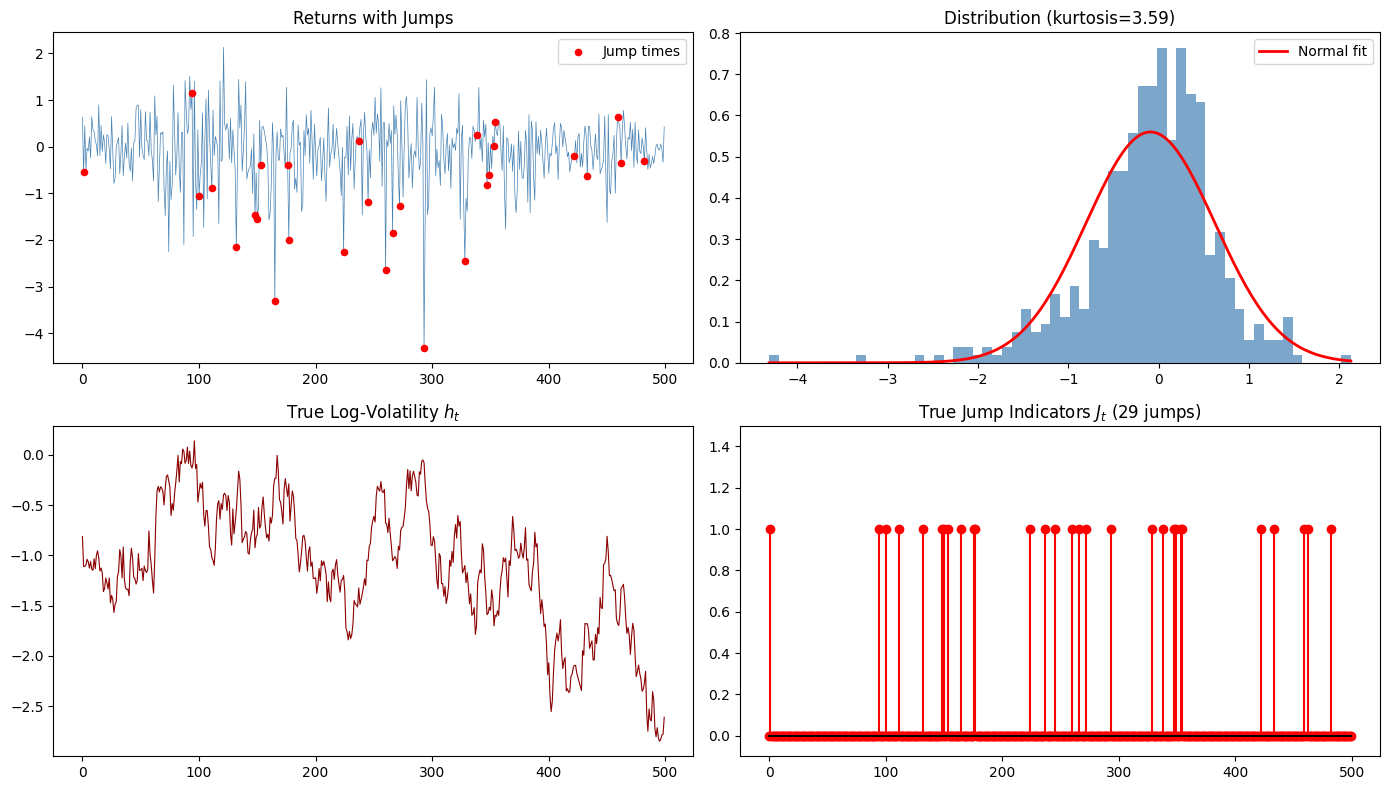

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Returns
axes[0, 0].plot(y_jumps, linewidth=0.5, color='steelblue')
jump_times = np.where(q_true_j > 0.5)[0]
axes[0, 0].scatter(jump_times, y_jumps[jump_times], color='red', s=20, zorder=5, label='Jump times')
axes[0, 0].set_title('Returns with Jumps')
axes[0, 0].legend()

# Histogram
axes[0, 1].hist(y_jumps, bins=60, density=True, alpha=0.7, color='steelblue')
x_grid = np.linspace(y_jumps.min(), y_jumps.max(), 200)
axes[0, 1].plot(x_grid, stats.norm.pdf(x_grid, y_jumps.mean(), y_jumps.std()),
               'r-', linewidth=2, label='Normal fit')
axes[0, 1].set_title(f'Distribution (kurtosis={stats.kurtosis(y_jumps):.2f})')
axes[0, 1].legend()

# True log-volatility
axes[1, 0].plot(h_true_j, linewidth=0.8, color='darkred')
axes[1, 0].set_title('True Log-Volatility $h_t$')

# True jump indicators
axes[1, 1].stem(range(len(q_true_j)), q_true_j, linefmt='r-', markerfmt='ro', basefmt='k-')
axes[1, 1].set_title(f'True Jump Indicators $J_t$ ({int(q_true_j.sum())} jumps)')
axes[1, 1].set_ylim(-0.1, 1.5)

plt.tight_layout()
plt.show()

### 1.3 Filtering SV-J with Auxiliary Particle Filter

The Auxiliary PF uses the predictive likelihood to pre-select particles, which is beneficial when observations are informative about the state (as with jumps).

In [4]:
def auxiliary_pf_svj(
    y: np.ndarray,
    params: dict,
    n_particles: int = 1000,
    seed: int = 42,
) -> dict:
    """Auxiliary PF for SV-J model. Returns filtered h, q, and log-likelihood."""
    rng = np.random.default_rng(seed)
    T = len(y)
    mu, phi, sigma = params['mu'], params['phi'], params['sigma']
    lam = params['lambda_jump']
    mu_j, sigma_j = params['mu_jump'], params['sigma_jump']
    
    var_stat = sigma**2 / (1.0 - phi**2)
    h_particles = rng.normal(mu, np.sqrt(var_stat), size=n_particles)
    q_particles = rng.binomial(1, lam, size=n_particles).astype(float)
    
    filtered_h_mean = np.zeros(T)
    filtered_h_std = np.zeros(T)
    filtered_q_mean = np.zeros(T)  # P(jump at t)
    log_lik = 0.0
    
    for t in range(T):
        # --- APF Stage 1: first-stage weights using predictive mean ---
        if t > 0:
            # Predictive h (deterministic part)
            h_pred = mu + phi * (h_particles - mu)
            q_pred_prob = lam * np.ones(n_particles)  # predicted jump probability
        else:
            h_pred = h_particles
            q_pred_prob = q_particles
        
        # First-stage weight: p(y_t | h_pred, q=0)*(1-lam) + p(y_t | h_pred, q=1)*lam
        vol_pred = np.exp(h_pred / 2.0)
        var_no = vol_pred**2
        var_yes = vol_pred**2 + sigma_j**2
        log_p_no = -0.5 * np.log(2 * np.pi * var_no) - 0.5 * y[t]**2 / var_no
        log_p_yes = -0.5 * np.log(2 * np.pi * var_yes) - 0.5 * (y[t] - mu_j)**2 / var_yes
        max_p = np.maximum(log_p_no, log_p_yes)
        first_w = (1 - lam) * np.exp(log_p_no - max_p) + lam * np.exp(log_p_yes - max_p)
        first_w_sum = np.sum(first_w)
        if first_w_sum < 1e-300:
            first_w = np.ones(n_particles) / n_particles
        else:
            first_w /= first_w_sum
        
        # Resample based on first-stage weights
        idx = rng.choice(n_particles, size=n_particles, p=first_w)
        h_particles = h_particles[idx]
        
        # --- Stage 2: propagate ---
        if t > 0:
            h_particles = mu + phi * (h_particles - mu) + sigma * rng.standard_normal(n_particles)
        q_particles = rng.binomial(1, lam, size=n_particles).astype(float)
        
        # --- Second-stage weights: p(y|h,q) / first-stage-approx ---
        vol = np.exp(h_particles / 2.0)
        var_no_2 = vol**2
        var_yes_2 = vol**2 + sigma_j**2
        log_p_actual = np.where(
            q_particles > 0.5,
            -0.5 * np.log(2 * np.pi * var_yes_2) - 0.5 * (y[t] - mu_j)**2 / var_yes_2,
            -0.5 * np.log(2 * np.pi * var_no_2) - 0.5 * y[t]**2 / var_no_2
        )
        
        # Normalize (simple version: equal adjustment weights)
        max_lw = np.max(log_p_actual)
        w = np.exp(log_p_actual - max_lw)
        sw = np.sum(w)
        if sw < 1e-300:
            w = np.ones(n_particles) / n_particles
            log_lik += -100.0  # penalty
        else:
            log_lik += max_lw + np.log(sw) - np.log(n_particles)
            w /= sw
        
        filtered_h_mean[t] = np.sum(w * h_particles)
        filtered_h_std[t] = np.sqrt(np.sum(w * (h_particles - filtered_h_mean[t])**2))
        filtered_q_mean[t] = np.sum(w * q_particles)
        
        # Resample for next step
        idx = rng.choice(n_particles, size=n_particles, p=w)
        h_particles = h_particles[idx]
        q_particles = q_particles[idx]
    
    return {
        'h_mean': filtered_h_mean,
        'h_std': filtered_h_std,
        'q_prob': filtered_q_mean,
        'log_likelihood': log_lik,
    }

# Run APF on SV-J data
params_j = {
    'mu': -1.0, 'phi': 0.97, 'sigma': 0.15,
    'lambda_jump': 0.05, 'mu_jump': -0.5, 'sigma_jump': 1.0,
}

t0 = time.time()
apf_result = auxiliary_pf_svj(y_jumps, params_j, n_particles=1000, seed=42)
elapsed = time.time() - t0
print(f'Auxiliary PF completed in {elapsed:.2f}s')
print(f'Log-likelihood: {apf_result["log_likelihood"]:.2f}')

Auxiliary PF completed in 0.14s
Log-likelihood: -488.67


### 1.4 Jump Detection

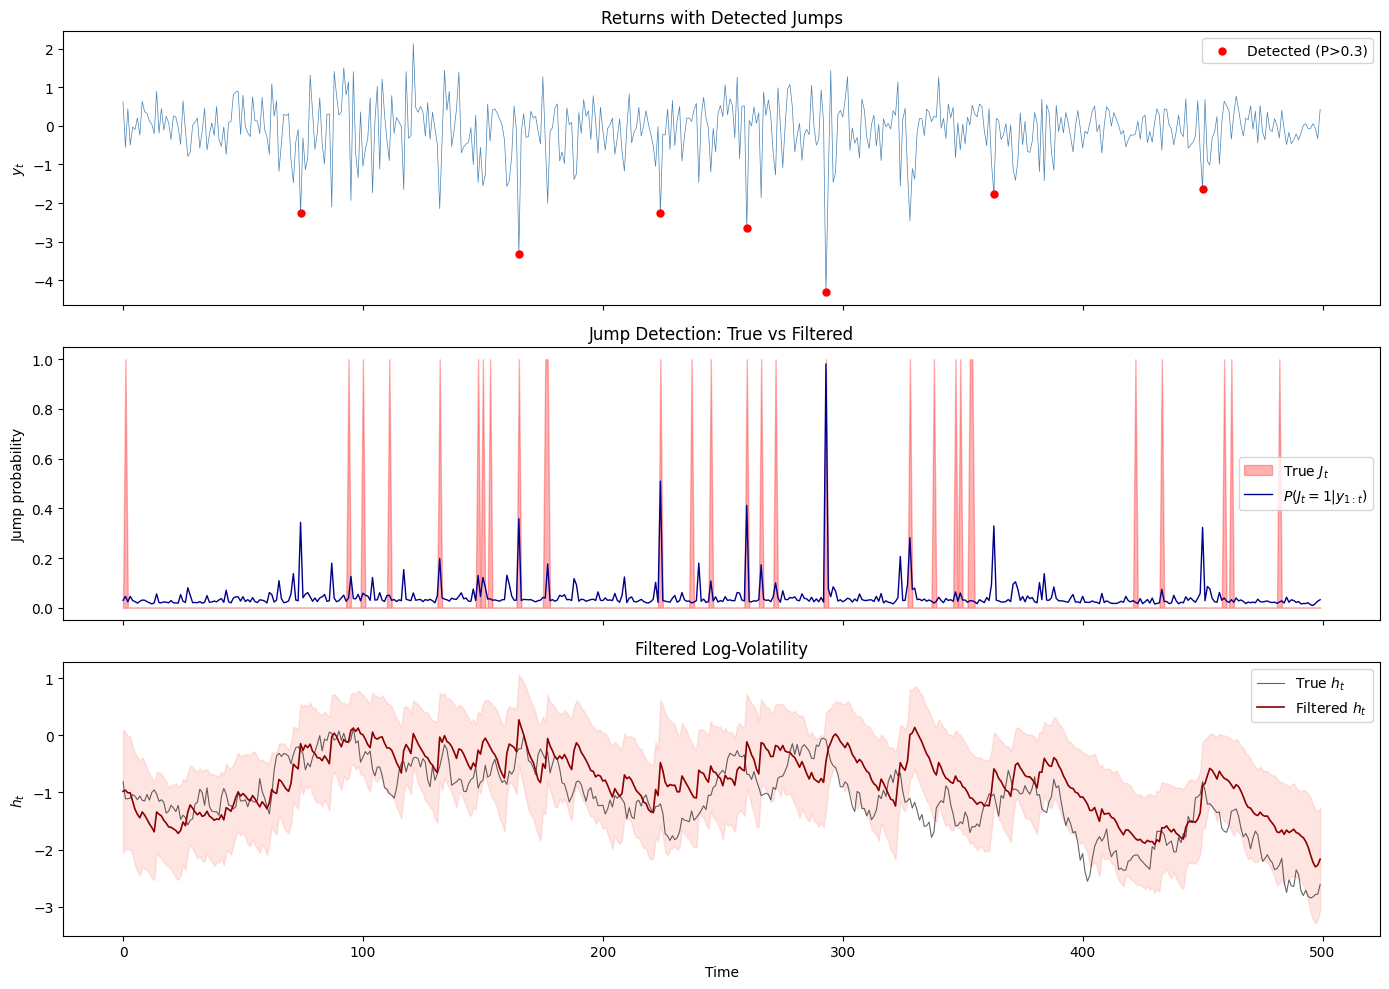


Jump detection (threshold=0.3):
  True positives: 4, False positives: 3, False negatives: 25
  Precision: 0.571, Recall: 0.138


In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Returns with detected jumps
axes[0].plot(y_jumps, linewidth=0.5, color='steelblue')
high_prob = apf_result['q_prob'] > 0.3
axes[0].scatter(np.where(high_prob)[0], y_jumps[high_prob],
               color='red', s=25, zorder=5, label='Detected (P>0.3)')
axes[0].set_title('Returns with Detected Jumps')
axes[0].set_ylabel('$y_t$')
axes[0].legend()

# True vs filtered jump probability
axes[1].fill_between(range(len(q_true_j)), q_true_j, alpha=0.3, color='red', label='True $J_t$')
axes[1].plot(apf_result['q_prob'], color='darkblue', linewidth=1, label='$P(J_t=1 | y_{1:t})$')
axes[1].set_title('Jump Detection: True vs Filtered')
axes[1].set_ylabel('Jump probability')
axes[1].legend()

# Filtered vs true log-volatility
axes[2].plot(h_true_j, color='black', linewidth=0.8, alpha=0.6, label='True $h_t$')
axes[2].plot(apf_result['h_mean'], color='darkred', linewidth=1.2, label='Filtered $h_t$')
h_upper = apf_result['h_mean'] + 1.96 * apf_result['h_std']
h_lower = apf_result['h_mean'] - 1.96 * apf_result['h_std']
axes[2].fill_between(range(len(h_true_j)), h_lower, h_upper, alpha=0.2, color='salmon')
axes[2].set_title('Filtered Log-Volatility')
axes[2].set_ylabel('$h_t$')
axes[2].set_xlabel('Time')
axes[2].legend()

plt.tight_layout()
plt.show()

# Detection metrics
threshold = 0.3
detected = apf_result['q_prob'] > threshold
true_jumps = q_true_j > 0.5
tp = np.sum(detected & true_jumps)
fp = np.sum(detected & ~true_jumps)
fn = np.sum(~detected & true_jumps)
precision = tp / max(tp + fp, 1)
recall = tp / max(tp + fn, 1)
print(f'\nJump detection (threshold={threshold}):')
print(f'  True positives: {tp}, False positives: {fp}, False negatives: {fn}')
print(f'  Precision: {precision:.3f}, Recall: {recall:.3f}')

## Part 2: Factor SV for Multiple Series

### 2.1 Synthetic Multivariate Data

The Factor SV model assumes $K$ observed series share a common volatility factor $h_t$ plus idiosyncratic volatility $h_{k,t}$:

$$y_{k,t} = \exp\bigl((\beta_k h_t + h_{k,t})/2\bigr)\,\varepsilon_{k,t}$$

In [6]:
# Generate factor SV data with 3 series
sv_factor = StochasticVolatility(
    variant='factor',
    k_factor_series=3,
    params={
        'mu': -1.0, 'phi': 0.97, 'sigma': 0.15,
        'phi_0': 0.95, 'sigma_0': 0.2, 'beta_0': 1.0,
        'phi_1': 0.90, 'sigma_1': 0.25, 'beta_1': 0.8,
        'phi_2': 0.93, 'sigma_2': 0.18, 'beta_2': 1.2,
    }
)

sim_f = sv_factor.simulate(T=500, seed=123)
y_factor = sim_f['observations']  # (T, 3)
states_f = sim_f['states']         # (T, 4): h_common, h_0, h_1, h_2
h_common_true = states_f[:, 0]

print(f'Factor SV: {y_factor.shape[1]} series, {y_factor.shape[0]} observations')
print(f'States shape: {states_f.shape} (common + {sv_factor.k_factor_series} idiosyncratic)')

Factor SV: 3 series, 500 observations
States shape: (500, 4) (common + 3 idiosyncratic)


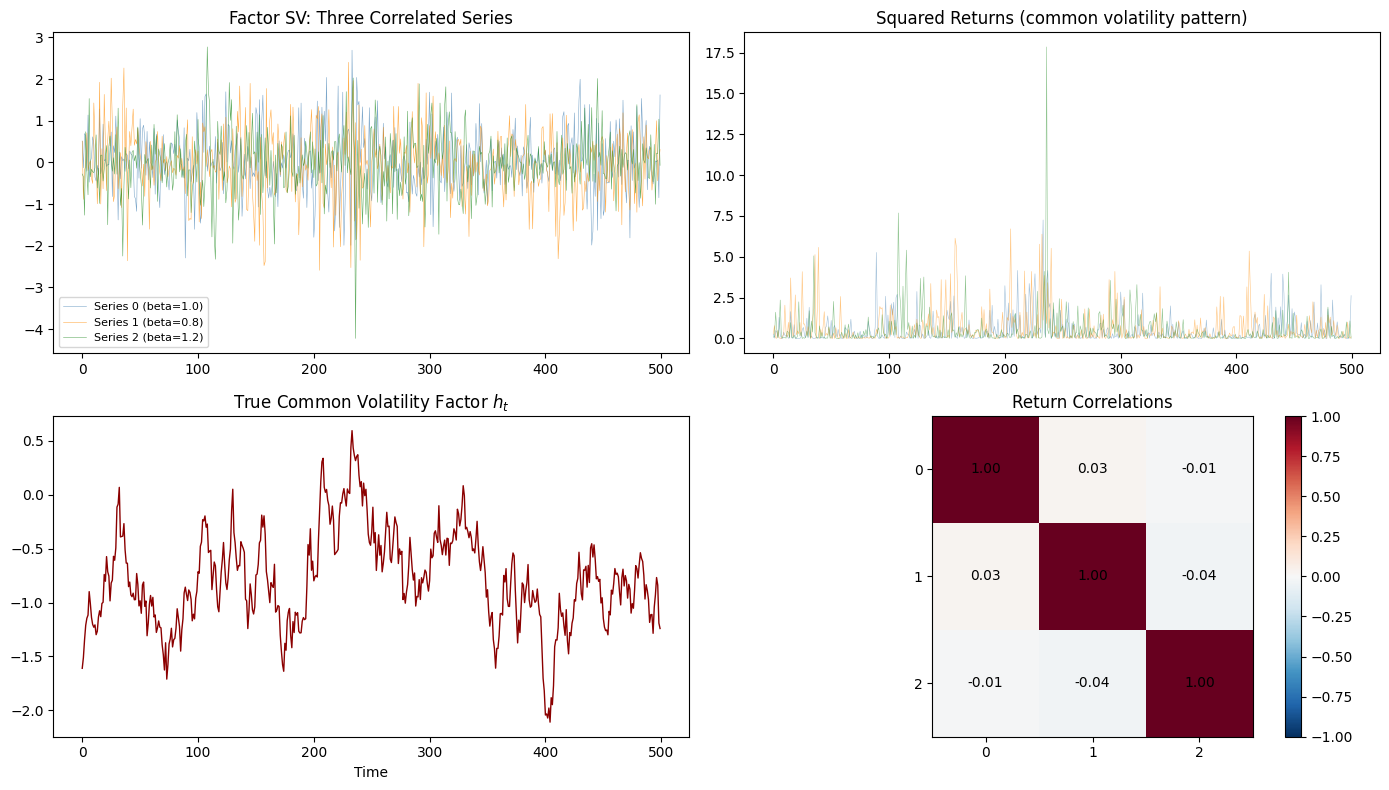

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
series_names = ['Series 0 (beta=1.0)', 'Series 1 (beta=0.8)', 'Series 2 (beta=1.2)']
colors = ['steelblue', 'darkorange', 'forestgreen']

# Individual series
for k in range(3):
    axes[0, 0].plot(y_factor[:, k], linewidth=0.4, color=colors[k], alpha=0.7, label=series_names[k])
axes[0, 0].set_title('Factor SV: Three Correlated Series')
axes[0, 0].legend(fontsize=8)

# Squared returns show common factor
for k in range(3):
    axes[0, 1].plot(y_factor[:, k]**2, linewidth=0.4, color=colors[k], alpha=0.5)
axes[0, 1].set_title('Squared Returns (common volatility pattern)')

# True common factor
axes[1, 0].plot(h_common_true, color='darkred', linewidth=1)
axes[1, 0].set_title('True Common Volatility Factor $h_t$')
axes[1, 0].set_xlabel('Time')

# Correlation matrix of returns
corr_mat = np.corrcoef(y_factor.T)
im = axes[1, 1].imshow(corr_mat, cmap='RdBu_r', vmin=-1, vmax=1)
axes[1, 1].set_title('Return Correlations')
axes[1, 1].set_xticks([0, 1, 2])
axes[1, 1].set_yticks([0, 1, 2])
for i in range(3):
    for j in range(3):
        axes[1, 1].text(j, i, f'{corr_mat[i,j]:.2f}', ha='center', va='center')
plt.colorbar(im, ax=axes[1, 1])

plt.tight_layout()
plt.show()

### 2.2 Filtering the Common Factor with RBPF

We use a particle filter that targets the common factor $h_t$, marginalizing over the idiosyncratic components where possible. For simplicity, we implement a bootstrap PF on the full state.

In [8]:
def pf_factor_sv(
    y: np.ndarray,
    params: dict,
    K: int = 3,
    n_particles: int = 500,
    seed: int = 42,
) -> dict:
    """Particle filter for Factor SV model.
    
    State: (h_common, h_0, h_1, ..., h_{K-1})
    Uses Rao-Blackwellization by marginalizing idiosyncratic components
    conditional on the common factor.
    """
    rng = np.random.default_rng(seed)
    T = y.shape[0]
    mu, phi, sigma = params['mu'], params['phi'], params['sigma']
    
    # Initialize common factor particles
    var_stat = sigma**2 / (1.0 - phi**2)
    h_common = rng.normal(mu, np.sqrt(var_stat), size=n_particles)
    
    # Initialize idiosyncratic states
    h_idio = np.zeros((n_particles, K))
    for k in range(K):
        phi_k = params[f'phi_{k}']
        sigma_k = params[f'sigma_{k}']
        var_k = sigma_k**2 / (1.0 - phi_k**2)
        h_idio[:, k] = rng.normal(0, np.sqrt(var_k), size=n_particles)
    
    filtered_h_common = np.zeros(T)
    filtered_h_common_std = np.zeros(T)
    log_lik = 0.0
    
    for t in range(T):
        # Compute log-weights: sum of log p(y_{k,t} | h_common, h_k)
        log_w = np.zeros(n_particles)
        for k in range(K):
            beta_k = params[f'beta_{k}']
            vol_k = np.exp((beta_k * h_common + h_idio[:, k]) / 2.0)
            log_w += -0.5 * np.log(2 * np.pi) - np.log(vol_k) - 0.5 * (y[t, k] / vol_k)**2
        
        max_lw = np.max(log_w)
        w = np.exp(log_w - max_lw)
        sw = np.sum(w)
        if sw < 1e-300:
            w = np.ones(n_particles) / n_particles
        else:
            log_lik += max_lw + np.log(sw) - np.log(n_particles)
            w /= sw
        
        filtered_h_common[t] = np.sum(w * h_common)
        filtered_h_common_std[t] = np.sqrt(np.sum(w * (h_common - filtered_h_common[t])**2))
        
        # Resample
        idx = rng.choice(n_particles, size=n_particles, p=w)
        h_common = h_common[idx]
        h_idio = h_idio[idx]
        
        # Propagate
        h_common = mu + phi * (h_common - mu) + sigma * rng.standard_normal(n_particles)
        for k in range(K):
            phi_k = params[f'phi_{k}']
            sigma_k = params[f'sigma_{k}']
            h_idio[:, k] = phi_k * h_idio[:, k] + sigma_k * rng.standard_normal(n_particles)
    
    return {
        'h_common_mean': filtered_h_common,
        'h_common_std': filtered_h_common_std,
        'log_likelihood': log_lik,
    }

# Run
params_f = {
    'mu': -1.0, 'phi': 0.97, 'sigma': 0.15,
    'phi_0': 0.95, 'sigma_0': 0.2, 'beta_0': 1.0,
    'phi_1': 0.90, 'sigma_1': 0.25, 'beta_1': 0.8,
    'phi_2': 0.93, 'sigma_2': 0.18, 'beta_2': 1.2,
}

t0 = time.time()
rbpf_result = pf_factor_sv(y_factor, params_f, K=3, n_particles=500, seed=42)
elapsed = time.time() - t0
print(f'Factor SV PF completed in {elapsed:.2f}s')
print(f'Log-likelihood: {rbpf_result["log_likelihood"]:.2f}')

# RMSE of common factor
rmse = np.sqrt(np.mean((rbpf_result['h_common_mean'] - h_common_true)**2))
print(f'RMSE of common factor h_t: {rmse:.4f}')

Factor SV PF completed in 0.07s
Log-likelihood: -1613.06
RMSE of common factor h_t: 0.3392


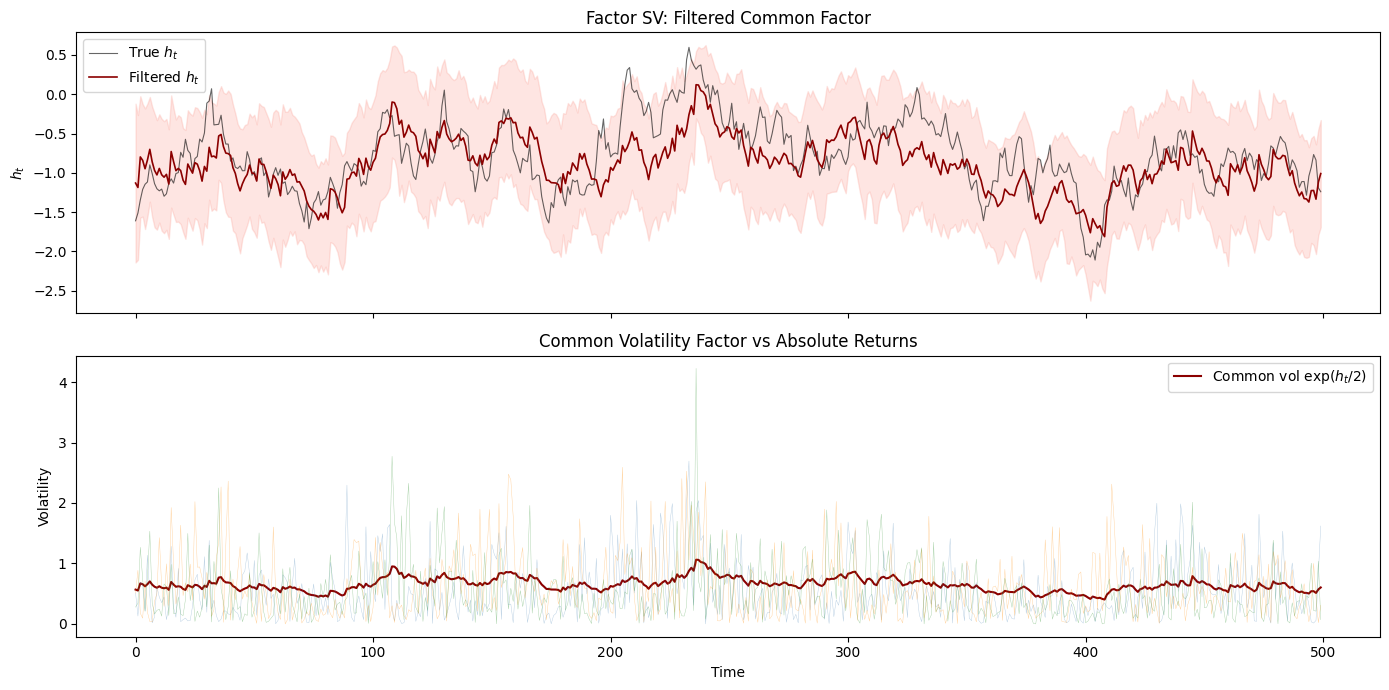

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Common factor
axes[0].plot(h_common_true, color='black', linewidth=0.8, alpha=0.6, label='True $h_t$')
axes[0].plot(rbpf_result['h_common_mean'], color='darkred', linewidth=1.2, label='Filtered $h_t$')
h_up = rbpf_result['h_common_mean'] + 1.96 * rbpf_result['h_common_std']
h_lo = rbpf_result['h_common_mean'] - 1.96 * rbpf_result['h_common_std']
axes[0].fill_between(range(len(h_common_true)), h_lo, h_up, alpha=0.2, color='salmon')
axes[0].set_title('Factor SV: Filtered Common Factor')
axes[0].set_ylabel('$h_t$')
axes[0].legend()

# Implied common volatility vs observed
vol_common = np.exp(rbpf_result['h_common_mean'] / 2.0)
axes[1].plot(vol_common, color='darkred', linewidth=1.5, label='Common vol $\\exp(h_t/2)$')
for k, (name, color) in enumerate(zip(series_names, colors)):
    axes[1].plot(np.abs(y_factor[:, k]), linewidth=0.3, color=color, alpha=0.4)
axes[1].set_title('Common Volatility Factor vs Absolute Returns')
axes[1].set_ylabel('Volatility')
axes[1].set_xlabel('Time')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Model Comparison: SV vs SV-L vs SV-J

In [10]:
# Load simulated_sv data for basic SV comparison
data_path_sv = os.path.join('..', 'data', 'simulated_sv.csv')
df_sv = pd.read_csv(data_path_sv)
y_basic = df_sv['y_obs'].values[:500]
h_true_basic = df_sv['h_true'].values[:500]

# Basic SV filter on basic data
def bootstrap_pf_basic(y, mu, phi, sigma, n_particles=1000, seed=42):
    rng = np.random.default_rng(seed)
    T = len(y)
    var_stat = sigma**2 / (1.0 - phi**2)
    particles = rng.normal(mu, np.sqrt(var_stat), size=n_particles)
    log_lik = 0.0
    rmse_sum = 0.0
    for t in range(T):
        vol = np.exp(particles / 2.0)
        log_w = -0.5 * np.log(2 * np.pi) - np.log(vol) - 0.5 * (y[t] / vol)**2
        max_lw = np.max(log_w)
        w = np.exp(log_w - max_lw)
        sw = np.sum(w)
        if sw < 1e-300:
            return {'log_likelihood': -np.inf}
        log_lik += max_lw + np.log(sw) - np.log(n_particles)
        w /= sw
        idx = rng.choice(n_particles, size=n_particles, p=w)
        particles = particles[idx]
        particles = mu + phi * (particles - mu) + sigma * rng.standard_normal(n_particles)
    return {'log_likelihood': log_lik}

ll_sv = bootstrap_pf_basic(y_basic, -1.0, 0.97, 0.15)['log_likelihood']

# Compare models
comparison = pd.DataFrame({
    'Model': ['SV Basic', 'SV-Leverage', 'SV-Jumps', 'Factor SV'],
    'State Dim': [1, 1, 2, '1+K'],
    'Parameters': [3, 4, 6, '3+3K'],
    'Key Feature': [
        'Baseline',
        'Corr(eps, eta) = rho',
        'Poisson jumps in returns',
        'Common + idiosyncratic vol',
    ],
    'Best For': [
        'Single series, no asymmetry',
        'Equity indices, options',
        'Crash-prone assets, FX',
        'Multi-asset portfolios',
    ],
})
print(comparison.to_string(index=False))
comparison

      Model State Dim Parameters                Key Feature                    Best For
   SV Basic         1          3                   Baseline Single series, no asymmetry
SV-Leverage         1          4       Corr(eps, eta) = rho     Equity indices, options
   SV-Jumps         2          6   Poisson jumps in returns      Crash-prone assets, FX
  Factor SV       1+K       3+3K Common + idiosyncratic vol      Multi-asset portfolios


,Model,State Dim,Parameters,Key Feature,Best For
0,SV Basic,1,3,Baseline,"Single series, no asymmetry"
1,SV-Leverage,1,4,"Corr(eps, eta) = rho","Equity indices, options"
2,SV-Jumps,2,6,Poisson jumps in returns,"Crash-prone assets, FX"
3,Factor SV,1+K,3+3K,Common + idiosyncratic vol,Multi-asset portfolios


## 4. Conclusion: Choosing the Right SV Model

| Data Characteristic | Recommended Model |
|---|---|
| Moderate volatility clustering | SV Basic |
| Asymmetric volatility response to positive/negative shocks | SV-Leverage |
| Fat tails with occasional extreme moves | SV-Jumps |
| Multiple correlated assets | Factor SV |

**Key takeaways:**

- **SV-J** can identify jump times with reasonable precision using the Auxiliary PF
- **Factor SV** extracts a common volatility driver from multiple series,
  enabling portfolio-level risk assessment
- The **Auxiliary PF** provides better particle allocation for SV-J than the Bootstrap PF
- All models are estimated within the `particlefilterbox` framework

For production use, combine model selection criteria (e.g., marginal likelihood via SMC$^2$)
with economic intuition about the data-generating process.